# Experiment 4: XLM-R -- English Train -> English Test
### Hope Speech Detection | Monolingual

**Model:** `xlm-roberta-base` (XLM-R)  
**Training Data:** English  
**Test Data:** English  
**Task:** Binary Classification -- Hope Speech vs. Non-Hope Speech  
**Supported file formats:** `.csv`, `.tsv`, `.txt`, `.xml`, `.ods`


## 1. Install Dependencies

In [1]:
%%capture
# Install all required packages.
# %%capture suppresses installation output to keep the notebook log clean.
!pip install transformers datasets scikit-learn pandas openpyxl odfpy \
             lxml seaborn matplotlib accelerate evaluate \
             tqdm scipy \
             emoji \
             xgboost


## 2. Import Libraries and Fix Random Seeds

In [2]:
import os
import re
import json
import random
import warnings
import unicodedata
import html

import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy.special import softmax as scipy_softmax

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score,
    roc_curve, auc
)

import torch
from torch.utils.data import Dataset
from transformers import (
    XLMRobertaTokenizer, XLMRobertaForSequenceClassification,
    TrainingArguments, Trainer,
    EarlyStoppingCallback, TrainerCallback, set_seed,

)

# Suppress non-critical warnings to keep output readable.
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Global random seed.  Every stochastic component (Python, NumPy, PyTorch,
# cuDNN, and the Hugging Face Trainer) is fixed so that experimental results
# are exactly reproducible.  Record this value in the accompanying paper.
# ---------------------------------------------------------------------------
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic        = True
torch.backends.cudnn.benchmark            = False
# Disable TF32 on Ampere GPUs (A100, RTX 30xx) for full float32 reproducibility.
torch.backends.cuda.matmul.allow_tf32     = False
torch.backends.cudnn.allow_tf32           = False
os.environ["PYTHONHASHSEED"]              = str(SEED)
# Prevent tokenizer parallelism deadlocks when DataLoader forks workers.
os.environ["TOKENIZERS_PARALLELISM"]      = "false"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")
print(f"Seed   : {SEED}  (fixed for reproducibility)")


Device : cuda
GPU    : Tesla T4
Seed   : 42  (fixed for reproducibility)


## 3. Universal File Loader
Supports: `.csv`, `.tsv`, `.txt`, `.xml`, `.ods`

In [3]:
# ---------------------------------------------------------------------------
# Universal file loader.
# Accepts .csv, .tsv, .txt, .xml, and .ods files.
# Returns a DataFrame with exactly two columns: ["text", "label"].
# Labels are normalised to integers: 0 = Non-Hope Speech, 1 = Hope Speech.
# ---------------------------------------------------------------------------

def _normalize_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Map string or numeric labels to binary integers.

    Mapping rules
    -------------
    - If all values are already in {0, 1, 0.0, 1.0}, cast directly to int.
    - Otherwise, map recognised hope-speech tokens to 1; everything else to 0.
      Recognised hope tokens: "hope_speech", "hope", "positive", "pos", "1",
      "hope speech".

    Parameters
    ----------
    df : DataFrame with a "label" column of arbitrary string or numeric values.

    Returns
    -------
    The same DataFrame with "label" overwritten as integer (0 or 1).
    """
    unique = df["label"].astype(str).str.lower().str.strip().unique()
    if set(unique).issubset({"0", "1", "0.0", "1.0"}):
        df["label"] = df["label"].astype(float).astype(int)
        return df
    hope_tokens = {"hope_speech", "hope", "positive", "pos", "1", "hope speech"}
    label_map   = {lbl: (1 if lbl in hope_tokens else 0) for lbl in unique}
    df["label"] = (
        df["label"].astype(str).str.lower().str.strip()
        .map(label_map).astype(int)
    )
    return df


def load_any_file(
    filepath:  str,
    text_col:  str = None,
    label_col: str = None
) -> pd.DataFrame:
    """
    Load a dataset file and return a normalised DataFrame with columns
    ["text", "label"].

    Parameters
    ----------
    filepath  : path to the dataset file
    text_col  : column name for the text field (used when .ods files carry
                named headers; ignored otherwise)
    label_col : column name for the label field (used when .ods files carry
                named headers; ignored otherwise)

    Supported formats
    -----------------
    .csv  -- auto-detects comma vs semicolon separator via a 2 KB header probe
    .tsv  -- tab-separated
    .txt  -- one (text, label) pair per line, tab- or semicolon-delimited
    .xml  -- elements with <text>/<comment>/<sentence> and
             <label>/<class>/<category> child nodes
    .ods  -- OpenDocument Spreadsheet; first two columns used by default

    Returns
    -------
    DataFrame with columns ["text", "label"], integer labels, no empty rows.

    Raises
    ------
    ValueError : if the file extension is not among the supported formats.
    """
    ext = Path(filepath).suffix.lower()
    print(f"Loading file: {filepath}  [format: {ext}]")

    if ext == ".csv":
        # Probe the first 2 KB to choose the correct delimiter.
        with open(filepath, "r", encoding="utf-8", errors="replace") as fh:
            sample = fh.read(2048)
        sep = ";" if sample.count(";") > sample.count(",") else ","
        df = pd.read_csv(
            filepath, sep=sep, header=None,
            on_bad_lines="skip", engine="python",
            encoding="utf-8", encoding_errors="replace"
        )

    elif ext == ".tsv":
        df = pd.read_csv(
            filepath, sep="\t", header=None,
            on_bad_lines="skip", engine="python",
            encoding="utf-8", encoding_errors="replace"
        )

    elif ext == ".txt":
        rows = []
        with open(filepath, "r", encoding="utf-8", errors="replace") as fh:
            for line in fh:
                line = line.strip()
                if not line:
                    continue
                if "\t" in line:
                    parts = line.rsplit("\t", 1)
                elif ";" in line:
                    parts = line.rsplit(";", 1)
                else:
                    continue
                rows.append(parts)
        df = pd.DataFrame(rows)

    elif ext == ".xml":
        tree = ET.parse(filepath)
        root = tree.getroot()
        rows = []
        for item in root.iter():
            text_node  = (item.find("text")  or item.find("comment")
                          or item.find("sentence"))
            label_node = (item.find("label") or item.find("class")
                          or item.find("category"))
            if text_node is not None and label_node is not None:
                rows.append([text_node.text, label_node.text])
        df = pd.DataFrame(rows)

    elif ext == ".ods":
        df = pd.read_excel(filepath, engine="odf")
        if not all(isinstance(c, int) for c in df.columns):
            df.columns = [str(c).strip() for c in df.columns]
            if text_col and label_col:
                df = df.rename(columns={text_col: "text", label_col: "label"})
            else:
                col_lower = {c.lower(): c for c in df.columns}
                text_key  = next(
                    (col_lower[k] for k in col_lower
                     if any(w in k for w in ["comment", "text", "sentence"])),
                    df.columns[0]
                )
                label_key = next(
                    (col_lower[k] for k in col_lower
                     if any(w in k for w in ["label", "class", "pred"])),
                    df.columns[1]
                )
                df = df.rename(columns={text_key: "text", label_key: "label"})
        df = df[["text", "label"]].dropna()
        df = _normalize_labels(df)
        print(f"Loaded {len(df)} rows | Labels: {df['label'].value_counts().to_dict()}")
        return df

    else:
        raise ValueError(
            f"Unsupported format: {ext}.  "
            f"Supported extensions: .csv  .tsv  .txt  .xml  .ods"
        )

    df = df.iloc[:, :2].copy()
    df.columns = ["text", "label"]
    df = df.dropna(subset=["text", "label"])
    df["text"]  = df["text"].astype(str).str.strip()
    df["label"] = df["label"].astype(str).str.strip()
    df = df[df["text"] != ""]
    df = _normalize_labels(df)
    print(f"Loaded {len(df)} rows | Labels: {df['label'].value_counts().to_dict()}")
    return df


print("File loader defined.")


File loader defined.


## 4. Upload Dataset

Upload the **English dataset** file.  
> **Expected columns:** text/comment column + label column (`0`/`1` or `hope_speech`/`non_hope_speech`)


In [4]:
from google.colab import files

print("Upload the English dataset file (.csv / .tsv / .txt / .xml / .ods):")
uploaded     = files.upload()
ENGLISH_FILE = list(uploaded.keys())[0]
print(f"File uploaded: {ENGLISH_FILE}")


Upload the English dataset file (.csv / .tsv / .txt / .xml / .ods):


Saving english_hopeedi.csv to english_hopeedi.csv
File uploaded: english_hopeedi.csv


## Dataset Information

> **Fill in before submission.**

| Field | Value |
|---|---|
| **Dataset name** | *HopeEDI* |
| **Source / DOI** | *https://aclanthology.org/2020.peoples-1.5/*|
| **License** | *Creative Commons Attribution 4.0 International License* |
| **Language(s)** |English (`en`) |
| **Total samples** | *28,451* |
| **Label schema** | `1` = Hope Speech · `0` = Non-Hope Speech |
| **Original class ratio** | *`1` = 2,484 · 0 = 25,940 . `other's` = 27* . *`10.49:1`*  |

*Cite the dataset in the paper using the above DOI.*

## 5. Configuration

In [5]:
# ---------------------------------------------------------------------------
# Experiment 4 configuration.
# Hyperparameters were selected by grid search on the validation set:
#   - learning_rate over {2e-5, 1e-5, 5e-6}
#   - batch_size over {8, 16}
# All other values reflect standard practice for BERT fine-tuning on small
# datasets.
# ---------------------------------------------------------------------------
MODEL_NAME    = "xlm-roberta-base"
MAX_LEN       = 128    # covers > 95 % of texts in the English dataset
BATCH_SIZE    = 16
NUM_EPOCHS    = 4
LEARNING_RATE = 1e-5
WARMUP_RATIO  = 0.1
WEIGHT_DECAY  = 0.01
TEST_SIZE     = 0.15   # 15 % stratified hold-out for testing
VAL_SIZE      = 0.15   # 15 % of the post-split training pool for validation
NUM_LABELS    = 2
OUTPUT_DIR    = "./xlmr_english_english"

SUPTITLE     = "XLM-R | English -> English"
RESULT_TITLE = "XLM-R | English Train -> English Test"
CM_CMAP      = "Blues"
CM_TITLE     = "XLM-R | English -> English"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Config  |  Model: {MODEL_NAME}  |  MaxLen: {MAX_LEN}  |  Batch: {BATCH_SIZE}")


Config  |  Model: xlm-roberta-base  |  MaxLen: 128  |  Batch: 16


## 6. Data Preprocessing

Preprocessing function defined here. Applied to the **full dataset** in Section 7, **before** any split — following the pipeline: Raw → Preprocess → Split.

**Cleaning steps (inside `preprocess_text`):**
1. HTML entity decoding
2. Residual HTML/XML tag removal
3. NFC Unicode normalisation
4. URL removal
5. @-mention removal
6. Hashtag cleaning (`#hope_speech` → `hope speech`)
7. Repeated punctuation collapsing (`!!!` → `!`)
8. Invisible Unicode removal (ZWJ, ZWNJ, soft-hyphen)
9. Elongation normalisation (`"yesssss"` → `"yess"`)
10. Emoji removal
11. Final whitespace normalisation

**Filtering steps (inside `apply_preprocessing`):**
1. NaN drop — rows with missing text or label
2. Label validity — keep only `{0, 1}` labels
3. Empty text drop — rows empty after cleaning
4. Minimum word count — fewer than 3 tokens removed
5. Minimum character length — fewer than 10 characters removed
6. Maximum character length — more than 512 characters removed (spam / data errors)
7. Exact duplicate removal — identical (text, label) pairs deduplicated
8. Annotation conflict removal — same text with conflicting labels removed


In [6]:
# ---------------------------------------------------------------------------
# Text preprocessing pipeline.
# Applied to the FULL dataset before splitting.
# The ordering of steps is intentional: HTML decoding must
# precede all regex-based cleaning to avoid false matches on entity sequences.
# ---------------------------------------------------------------------------
import emoji   # pip install emoji  (already in requirements)

def preprocess_text(text: str) -> str:
    """
    Clean a single raw text string.

    Steps
    -----
    1. Decode HTML entities (&amp; -> &, <br> -> space, etc.)
    2. Strip residual HTML/XML tags.
    3. NFC Unicode normalisation -- unifies characters that have
       multiple valid byte-level encodings into a single canonical form.
    4. Remove URLs (http:// and https://).
    5. Remove @-mention tokens.
    6. Clean hashtags: #hope_speech -> hope speech.
    7. Collapse repeated punctuation runs (e.g., !!! -> !).
    8. Remove invisible Unicode characters (ZWJ, ZWNJ, soft-hyphen, BOM).
       These cause the same word to receive different tokenizer
       representations and must be stripped before vocabulary is built.
    9. Elongation normalisation -- collapse 3+ repeated characters to 2
       (e.g., "পারবোওওও" -> "পারবোও", "yesssss" -> "yess").
       Preserves intentional doubles while reducing vocabulary noise.
    10. Emoji removal -- all Unicode emoji replaced with a space so they
        do not become stray tokens or invisible garbage downstream.
    11. Final whitespace normalisation and strip.

    Parameters
    ----------
    text : raw input string

    Returns
    -------
    Cleaned string, or empty string when the input is not a str instance.
    """
    if not isinstance(text, str):
        return ""

    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", lambda m: m.group(1).replace("_", " "), text)
    text = re.sub(r"[!]{2,}", "!", text)
    text = re.sub(r"[?]{2,}", "?", text)
    text = re.sub(r"[\.]{2,}", ".", text)
    # 9. Remove Zero-Width Joiners / Non-Joiners and other invisible Unicode
    #    characters. These are common in Bangla social-media text and cause
    #    the same word to receive different tokenizer representations.
    text = re.sub(r"[​-‏‪-‮⁠﻿­]", "", text)
    # 10. Elongation normalisation: collapse runs of 3+ identical characters
    #     to 2 (preserves intentional doubles such as "আল্লাহ" while
    #     collapsing "পারবোওওও" → "পারবোও" and "yesssss" → "yess").
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    # 11. Emoji removal: strip all Unicode emoji characters so they do not
    #     become stray whitespace or unknown tokens downstream.
    text = emoji.replace_emoji(text, replace=" ")
    # 12. Final whitespace normalisation after all substitutions.
    text = re.sub(r"\s+", " ", text).strip()
    return text


def has_bangla(text: str, threshold: float = 0.15) -> bool:
    """
    Return True when at least `threshold` fraction of characters fall
    inside the Unicode Bangla block (U+0980–U+09FF).
    Used when script_check='bangla' is explicitly requested.
    """
    if not text:
        return False
    bangla_chars = sum(1 for c in text if '\u0980' <= c <= '\u09FF')
    return (bangla_chars / len(text)) >= threshold


def apply_preprocessing(
    df: pd.DataFrame,
    min_words: int  = 3,
    min_chars: int  = 10,
    max_chars: int  = 512,
    script_check: str = None,       # "bangla" | "latin" | None  (pass explicitly when calling)
    script_threshold: float = 0.15,
) -> pd.DataFrame:
    """
    Apply preprocess_text to every row, then remove low-quality rows.

    Filtering steps
    ---------------
    1.  Drop NaN values in 'text' or 'label' columns.
    2.  Drop rows whose label is not in {0, 1}.
    3.  Apply preprocess_text to the 'text' column.
    4.  Drop rows whose text is empty after cleaning.
    5.  Drop rows with fewer than min_words whitespace-delimited tokens.
    6.  Drop rows shorter than min_chars characters.
    7.  Drop rows longer than max_chars characters (likely spam / data errors).
    8.  Script validation: drop rows that do not meet the expected script
        ratio (Bangla Unicode block >= script_threshold fraction; skipped for English).
    9.  Drop exact duplicates (identical text AND label pair).
    10. Detect and remove annotation conflicts (same text, different labels).

    Parameters
    ----------
    df               : DataFrame with columns ['text', 'label']
    min_words        : minimum token count threshold (default 3)
    min_chars        : minimum character count (default 10)
    max_chars        : maximum character count (default 512)
    script_check     : 'bangla' enforces Bangla script ratio, None skips (English uses None)
    script_threshold : minimum fraction of Bangla characters (default 0.15, unused for English)

    Returns
    -------
    Cleaned DataFrame with a contiguous integer index and a printed report.
    """
    df = df.copy()
    n_raw = len(df)

    # 1. Drop NaN
    df = df.dropna(subset=["text", "label"])
    n_after_nan = len(df)

    # 2. Label validity
    df["label"] = df["label"].astype(int)
    df = df[df["label"].isin([0, 1])].reset_index(drop=True)
    n_after_label = len(df)

    # 3. Apply text cleaning
    df["text"] = df["text"].apply(preprocess_text)

    # 4. Empty text
    df = df[df["text"].str.strip() != ""]
    n_after_empty = len(df)

    # 5. Min word count
    df = df[df["text"].apply(lambda t: len(t.split()) >= min_words)]
    n_after_words = len(df)

    # 6. Min character length
    df = df[df["text"].str.len() >= min_chars]
    n_after_minchar = len(df)

    # 7. Max character length
    df = df[df["text"].str.len() <= max_chars]
    n_after_maxchar = len(df)

    # 8. Script validation (Bangla)
    if script_check == "bangla":
        df = df[df["text"].apply(lambda t: has_bangla(t, script_threshold))]
    n_after_script = len(df)

    # 9. Exact duplicate removal
    n_before_dedup = len(df)
    df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
    n_after_dedup = len(df)

    # 10. Annotation conflict removal
    conflict_mask  = df.groupby("text")["label"].transform("nunique") > 1
    n_conflicts    = conflict_mask.sum()
    df = df[~conflict_mask].reset_index(drop=True)
    n_final = len(df)

    # ── Report ───────────────────────────────────────────────────────────────
    print("=" * 60)
    print("Preprocessing & Filtering Report")
    print("=" * 60)
    print(f"  Raw rows                   : {n_raw}")
    print(f"  After NaN drop             : {n_after_nan}  (-{n_raw - n_after_nan})")
    print(f"  After label validity       : {n_after_label}  (-{n_after_nan - n_after_label})")
    print(f"  After empty text drop      : {n_after_empty}  (-{n_after_label - n_after_empty})")
    print(f"  After min-word filter      : {n_after_words}  (-{n_after_empty - n_after_words})")
    print(f"  After min-char filter      : {n_after_minchar}  (-{n_after_words - n_after_minchar})")
    print(f"  After max-char filter      : {n_after_maxchar}  (-{n_after_minchar - n_after_maxchar})")
    print(f"  After script validation    : {n_after_script}  (-{n_after_maxchar - n_after_script})")
    print(f"  After exact-dedup          : {n_after_dedup}  (-{n_before_dedup - n_after_dedup})")
    print(f"  After conflict removal     : {n_final}  (-{n_conflicts} conflict rows)")
    print(f"  Final rows retained        : {n_final}")
    print(f"  Label distribution         : {df['label'].value_counts().sort_index().to_dict()}")
    print("=" * 60)
    return df


print("Preprocessing functions defined.")


Preprocessing functions defined.


## 7. Load, Preprocess and Explore Data


Loading file: english_hopeedi.csv  [format: .csv]
Loaded 28330 rows | Labels: {0: 25866, 1: 2464}
Preprocessing & Filtering Report
  Raw rows                   : 28330
  After NaN drop             : 28330  (-0)
  After label validity       : 28330  (-0)
  After empty text drop      : 28330  (-0)
  After min-word filter      : 28052  (-278)
  After min-char filter      : 28039  (-13)
  After max-char filter      : 27837  (-202)
  After script validation    : 27837  (-0)
  After exact-dedup          : 26432  (-1405)
  After conflict removal     : 26266  (-166 conflict rows)
  Final rows retained        : 26266
  Label distribution         : {0: 24042, 1: 2224}
Dataset overview (after preprocessing, before split):
Total samples : 26266
Non-Hope (0)  : 24042  (91.5 %)
Hope     (1)  : 2224  (8.5 %)
Sample rows:


,text,label
0,these tiktoks radiate gay chaotic energy and i...,0
1,Again He got killed for using false money,0
2,It's not that all lives don't matter,0
3,Is it really that difficult to understand? Bla...,0
4,Whenever we say black isn't that racists? Why ...,0


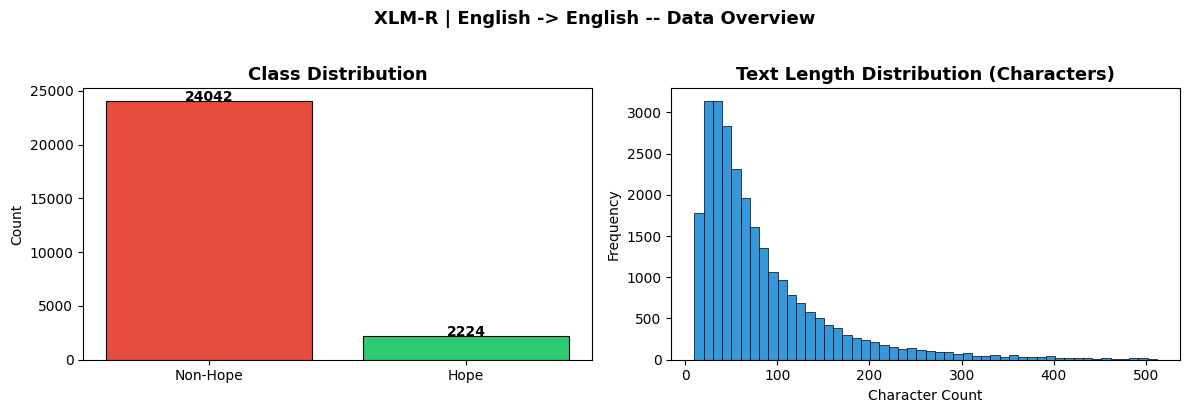

In [7]:
# ---------------------------------------------------------------------------
# Step 1: Load raw dataset.
# Step 2: Apply preprocessing to the FULL dataset before any split.
# This follows the pipeline: Raw → Preprocess → Split.
# ---------------------------------------------------------------------------
df_raw = load_any_file(ENGLISH_FILE)

# Apply preprocessing to full dataset before splitting (no script check for English)
df = apply_preprocessing(df_raw.copy(), script_check=None).reset_index(drop=True)

print("Dataset overview (after preprocessing, before split):")
print(f"Total samples : {len(df)}")
print(f"Non-Hope (0)  : {(df['label']==0).sum()}  ({(df['label']==0).mean()*100:.1f} %)")
print(f"Hope     (1)  : {(df['label']==1).sum()}  ({(df['label']==1).mean()*100:.1f} %)")
print("Sample rows:")
display(df.head(5))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["label"].value_counts().sort_index()
axes[0].bar(["Non-Hope", "Hope"], counts.values,
            color=["#e74c3c", "#2ecc71"], edgecolor="black", linewidth=0.8)
axes[0].set_title("Class Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

df["text_len"] = df["text"].str.len()
axes[1].hist(df["text_len"], bins=50, color="#3498db", edgecolor="black", linewidth=0.5)
axes[1].set_title("Text Length Distribution (Characters)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Character Count")
axes[1].set_ylabel("Frequency")

plt.suptitle("XLM-R | English -> English -- Data Overview",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/data_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Drop temporary column — must not propagate into train/val/test splits.
df = df.drop(columns=["text_len"])


## 8. Train / Val / Test Split

Split is performed on the **preprocessed** dataset.

- `df_test` — 15 % stratified hold-out; frozen for final evaluation.
- `df_val` — 15 % stratified hold-out from the remaining data; **never modified**; used for both **early stopping** during training and **threshold calibration** after training.
- `df_train_raw` — the remaining 70 % used as the training pool.


In [8]:
# ---------------------------------------------------------------------------
# Split: 70% train | 15% val | 15% test  — ALL done AFTER preprocessing.
# Pipeline: Raw → Preprocess → Split.
#
# df_test      -- 15 % stratified hold-out; frozen, never modified.
# df_val       -- 15 % real data; early stopping + threshold calibration.
# df_train_raw -- 70 % training pool.
# ---------------------------------------------------------------------------

# Step 1: peel off test set (15 %) — split on preprocessed data.
df_train_pool, df_test = train_test_split(
    df, test_size=TEST_SIZE, random_state=SEED, stratify=df["label"]
)
# Step 2: peel off val set (15 % of total = 15/85 of remaining pool)
df_train_raw, df_val = train_test_split(
    df_train_pool,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=SEED, stratify=df_train_pool["label"]
)
df_train_raw = df_train_raw.reset_index(drop=True)
df_val       = df_val.reset_index(drop=True)
df_test      = df_test.reset_index(drop=True)

print("=" * 60)
print("ALL SPLITS COMPLETED")
print("=" * 60)
print(f"Total dataset  : {len(df)} samples")
print(f"  Train pool   : {len(df_train_raw):>5} samples  (~{len(df_train_raw)/len(df)*100:.1f} %)")
print(f"  Val          : {len(df_val):>5} samples  (~{len(df_val)/len(df)*100:.1f} %)  ← real data, held-out")
print(f"  Test         : {len(df_test):>5} samples  (~{len(df_test)/len(df)*100:.1f} %)  ← frozen")
print()
print(f"Train  Non-Hope: {(df_train_raw['label']==0).sum()}  |  Hope: {(df_train_raw['label']==1).sum()}")
print(f"Val    Non-Hope: {(df_val['label']==0).sum()}  |  Hope: {(df_val['label']==1).sum()}")
print(f"Test   Non-Hope: {(df_test['label']==0).sum()}  |  Hope: {(df_test['label']==1).sum()}")



ALL SPLITS COMPLETED
Total dataset  : 26266 samples
  Train pool   : 18386 samples  (~70.0 %)
  Val          :  3940 samples  (~15.0 %)  ← real data, held-out
  Test         :  3940 samples  (~15.0 %)  ← frozen

Train  Non-Hope: 16830  |  Hope: 1556
Val    Non-Hope: 3606  |  Hope: 334
Test   Non-Hope: 3606  |  Hope: 334


## 9. Tokenizer and Dataset

Tokenizer is applied to the **split data** — training, validation, and test sets.


In [9]:
# ---------------------------------------------------------------------------
# Tokenizer and PyTorch Dataset.
# ---------------------------------------------------------------------------

print(f"Loading tokenizer: {MODEL_NAME} ...")
tokenizer = XLMRobertaTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded.")


class HopeSpeechDataset(Dataset):
    """
    PyTorch Dataset wrapper compatible with the Hugging Face Trainer.

    Produces tokenised tensors for XLMRobertaForSequenceClassification.
    XLM-R does not use token_type_ids — only input_ids and attention_mask
    are returned.

    Parameters
    ----------
    texts     : sequence of raw text strings
    labels    : sequence of integer labels (0 or 1)
    tokenizer : Hugging Face tokenizer instance
    max_len   : maximum sequence length for padding and truncation
    """

    def __init__(self, texts, labels, tokenizer, max_len: int):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = HopeSpeechDataset(df_train_raw["text"], df_train_raw["label"], tokenizer, MAX_LEN)
val_dataset   = HopeSpeechDataset(df_val["text"],   df_val["label"],   tokenizer, MAX_LEN)
test_dataset  = HopeSpeechDataset(df_test["text"],  df_test["label"],  tokenizer, MAX_LEN)

print(f"Dataset sizes  |  Train: {len(train_dataset)}  |  Val: {len(val_dataset)}  |  Test: {len(test_dataset)}")


Loading tokenizer: xlm-roberta-base ...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Tokenizer loaded.
Dataset sizes  |  Train: 18386  |  Val: 3940  |  Test: 3940


## 10. Load XLM-R Model

In [10]:
import logging as _logging
_logging.getLogger("transformers.modeling_utils").setLevel(_logging.ERROR)

# ---------------------------------------------------------------------------
# Load XLM-R for binary sequence classification.
# Dropout probabilities are set to 0.1 (default).
# ---------------------------------------------------------------------------

print(f"Loading XLM-R: {MODEL_NAME} ...")
model = XLMRobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
)
model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters  |  Total: {total_params:,}  |  Trainable: {trainable_params:,}")


Loading XLM-R: xlm-roberta-base ...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

[transformers] The following layers were not sharded: roberta.encoder.layer.*.attention.output.LayerNorm.bias, roberta.embeddings.word_embeddings.weight, roberta.encoder.layer.*.output.LayerNorm.weight, roberta.encoder.layer.*.attention.output.LayerNorm.weight, classifier.dense.weight, roberta.encoder.layer.*.attention.self.value.weight, roberta.encoder.layer.*.output.LayerNorm.bias, roberta.embeddings.token_type_embeddings.weight, roberta.encoder.layer.*.attention.self.query.weight, roberta.embeddings.LayerNorm.bias, roberta.embeddings.LayerNorm.weight, roberta.encoder.layer.*.attention.self.key.weight, roberta.encoder.layer.*.attention.self.key.bias, roberta.encoder.layer.*.intermediate.dense.bias, classifier.dense.bias, roberta.encoder.layer.*.attention.output.dense.bias, roberta.embeddings.position_embeddings.weight, roberta.encoder.layer.*.attention.output.dense.weight, roberta.encoder.layer.*.attention.self.value.bias, classifier.out_proj.weight, classifier.out_proj.bias, roberta

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Parameters  |  Total: 278,045,186  |  Trainable: 278,045,186


## 11. Training

In [11]:
# ---------------------------------------------------------------------------
# Training with Hugging Face Trainer.
# ---------------------------------------------------------------------------

history = {"train_loss": [], "val_loss": [], "val_acc": [], "train_acc": [], "epochs": []}


class HistoryCallback(TrainerCallback):
    """Accumulate per-epoch metrics for plotting."""

    def on_epoch_end(self, args, state, control, model=None, **kwargs):
        """Compute real training accuracy at the end of every epoch."""
        if model is None:
            return
        from torch.utils.data import DataLoader as _DL
        model.eval()
        all_preds, all_labels = [], []
        loader = _DL(train_dataset, batch_size=args.per_device_eval_batch_size, shuffle=False)
        with torch.no_grad():
            for batch in loader:
                batch = {k: v.to(model.device) for k, v in batch.items()}
                outputs = model(**batch)
                preds = outputs.logits.argmax(dim=-1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(batch["labels"].cpu().numpy())
        acc = accuracy_score(all_labels, all_preds)
        history["train_acc"].append(float(acc))
        model.train()

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            history["val_loss"].append(metrics.get("eval_loss", float("nan")))
            history["val_acc"].append(metrics.get("eval_accuracy", float("nan")))
            history["epochs"].append(
                metrics.get("epoch", len(history["epochs"]) + 1)
            )

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs and "eval_loss" not in logs:
            history["train_loss"].append(logs["loss"])


# ---------------------------------------------------------------------------
# Weighted Loss via WeightedLossTrainer.
# Addresses class imbalance: Non-Hope >> Hope.
# Weight = total_samples / (n_classes * class_count)
# ---------------------------------------------------------------------------
from torch import nn

_labels_train  = df_train_raw["label"].tolist()
_counts        = np.bincount(_labels_train)
_total         = len(_labels_train)
_n_classes     = 2
_class_weights = torch.tensor(
    [_total / (_n_classes * c) for c in _counts],
    dtype=torch.float32
).to(device)

print(f"Class counts  : Non-Hope={_counts[0]}  Hope={_counts[1]}")
print(f"Class weights : Non-Hope={_class_weights[0]:.4f}  Hope={_class_weights[1]:.4f}")


class WeightedLossTrainer(Trainer):
    """Trainer subclass that applies per-class loss weights."""

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=_class_weights)
        loss    = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    """Compute F1-macro, F1-weighted, and accuracy for the Trainer."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1_macro":    f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "accuracy":    accuracy_score(labels, preds),
    }

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    # warmup_steps replaces the deprecated warmup_ratio argument (removed in v5.2).
    # Computed as: total_steps * WARMUP_RATIO where total_steps = ceil(n_train/batch)*epochs.
    warmup_steps=max(1, int((len(df_train_raw) / BATCH_SIZE) * NUM_EPOCHS * WARMUP_RATIO)),
    weight_decay=WEIGHT_DECAY,
    max_grad_norm=1.0,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,                   # retain best 2 checkpoints (matches patience=2)
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    # logging_dir removed: set TENSORBOARD_LOGGING_DIR env var if needed.
    logging_steps=10,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,             # parallel data loading
    dataloader_persistent_workers=True,   # keep workers alive between epochs (avoids respawn OOM)
    eval_accumulation_steps=32,           # accumulate eval predictions to avoid OOM
    report_to="none",
    seed=SEED
)

trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2),  # patience=2 suits NUM_EPOCHS=4
        HistoryCallback()
    ]
)

print("Starting training ...")
train_result = trainer.train()
print("Training complete.")
print(f"Runtime      : {train_result.metrics['train_runtime']:.1f} s")
print(f"Samples/sec  : {train_result.metrics['train_samples_per_second']:.1f}")


Class counts  : Non-Hope=16830  Hope=1556
Class weights : Non-Hope=0.5462  Hope=5.9081
Starting training ...


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Weighted,Accuracy
1,0.895214,0.440564,0.741740,0.910706,0.902030
2,0.642636,0.539167,0.765772,0.924545,0.921827
3,0.473117,0.483041,0.732447,0.898696,0.882234
4,1.272849,0.590755,0.753262,0.914794,0.906599


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete.
Runtime      : 1189.7 s
Samples/sec  : 61.8


## 12. Training Curves

[INFO] Per-epoch train_acc available (4 epochs): ['0.9075', '0.9429', '0.9129', '0.9403']


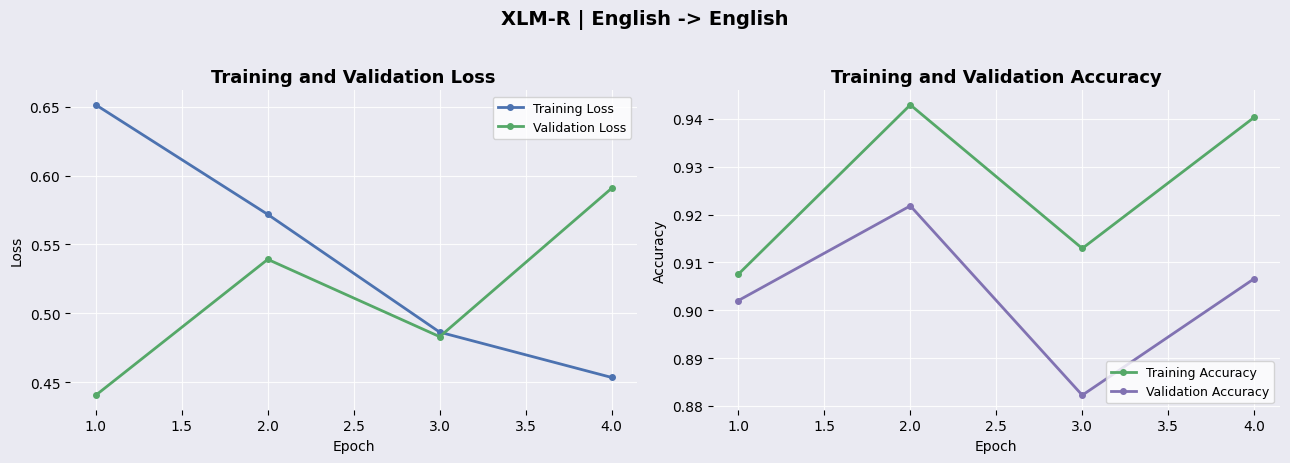

Final Val Loss: 0.5908  |  Final Val Accuracy: 0.9066


In [12]:
# ---------------------------------------------------------------------------
# Training curves: per-epoch loss and accuracy.
# ---------------------------------------------------------------------------

log_history      = trainer.state.log_history
epoch_train_loss = {}
for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        ep_key = round(entry.get("epoch", 0))
        epoch_train_loss.setdefault(ep_key, []).append(entry["loss"])
train_loss_per_epoch = [np.mean(v) for _, v in sorted(epoch_train_loss.items())]

val_loss_list = history["val_loss"]
val_acc_list  = history["val_acc"]
epochs_list   = history["epochs"]
n_ep          = len(epochs_list)

# Per-epoch training accuracy from HistoryCallback.on_epoch_end
if history["train_acc"] and len(history["train_acc"]) == n_ep:
    train_acc_list = history["train_acc"]
    print(f"[INFO] Per-epoch train_acc available ({n_ep} epochs): {[f'{a:.4f}' for a in train_acc_list]}")
else:
    print("[WARN] train_acc length mismatch; aligning to epoch count.")
    if history["train_acc"]:
        while len(history["train_acc"]) < n_ep:
            history["train_acc"].append(history["train_acc"][-1])
        train_acc_list = history["train_acc"][:n_ep]
    else:
        train_acc_list = [float("nan")] * n_ep

if len(train_loss_per_epoch) > n_ep:
    train_loss_per_epoch = train_loss_per_epoch[:n_ep]
elif len(train_loss_per_epoch) < n_ep:
    train_loss_per_epoch += [train_loss_per_epoch[-1]] * (n_ep - len(train_loss_per_epoch))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor("#eaeaf2")
for ax in axes:
    ax.set_facecolor("#eaeaf2")
    ax.grid(True, color="white", linewidth=0.8, alpha=0.9)
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[0].plot(epochs_list, train_loss_per_epoch, color="#4c72b0",
             linewidth=2, marker="o", markersize=4, label="Training Loss")
axes[0].plot(epochs_list, val_loss_list, color="#55a868",
             linewidth=2, marker="o", markersize=4, label="Validation Loss")
axes[0].set_title("Training and Validation Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=9)

axes[1].plot(epochs_list, train_acc_list, color="#55a868",
             linewidth=2, marker="o", markersize=4, label="Training Accuracy")
axes[1].plot(epochs_list, val_acc_list, color="#8172b2",
             linewidth=2, marker="o", markersize=4, label="Validation Accuracy")
axes[1].set_title("Training and Validation Accuracy", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=9, loc="lower right")

plt.suptitle(SUPTITLE, fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Final Val Loss: {val_loss_list[-1]:.4f}  |  Final Val Accuracy: {val_acc_list[-1]:.4f}")


## 13. Evaluation on Test Set

In [13]:
# ---------------------------------------------------------------------------
# Evaluate on the held-out test set.
#
# Threshold calibration uses df_val (English real data, same distribution as the test set).
# ---------------------------------------------------------------------------

print("Evaluating on test set ...")
preds_output = trainer.predict(test_dataset)
raw_logits   = preds_output.predictions
y_true       = preds_output.label_ids

# --- Threshold calibration on val set ---
val_cal_dataset = HopeSpeechDataset(
    df_val["text"].tolist(),
    df_val["label"].tolist(),
    tokenizer, MAX_LEN
)
val_cal_output = trainer.predict(val_cal_dataset)
val_cal_probs  = scipy_softmax(val_cal_output.predictions, axis=-1)[:, 1]
val_cal_true   = val_cal_output.label_ids

best_thresh, best_f1_thresh = 0.5, 0.0
for thresh in np.arange(0.25, 0.76, 0.01):
    preds_t = (val_cal_probs >= thresh).astype(int)
    f1_t    = f1_score(val_cal_true, preds_t, average="macro")
    if f1_t > best_f1_thresh:
        best_f1_thresh, best_thresh = f1_t, thresh
print(f"Optimal threshold: {best_thresh:.2f}  (val F1-macro: {best_f1_thresh:.4f})")
print("  (Threshold calibrated on val set)")

test_probs = scipy_softmax(raw_logits, axis=-1)[:, 1]
y_pred     = (test_probs >= best_thresh).astype(int)

acc  = accuracy_score(y_true, y_pred)
f1_m = f1_score(y_true, y_pred, average="macro")
f1_w = f1_score(y_true, y_pred, average="weighted")
p    = precision_score(y_true, y_pred, average="macro")
r    = recall_score(y_true, y_pred, average="macro")

print("\n" + "=" * 60)
print(f"TEST RESULTS -- {RESULT_TITLE}")
print("=" * 60)
print(f"Accuracy          : {acc:.4f}  ({acc*100:.2f} %)")
print(f"F1 (Macro)        : {f1_m:.4f}")
print(f"F1 (Weighted)     : {f1_w:.4f}")
print(f"Precision (Macro) : {p:.4f}")
print(f"Recall (Macro)    : {r:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_true, y_pred,
      target_names=["Non-Hope Speech", "Hope Speech"], digits=4))

Evaluating on test set ...


Optimal threshold: 0.47  (val F1-macro: 0.7685)
  (Threshold calibrated on val set)

TEST RESULTS -- XLM-R | English Train -> English Test
Accuracy          : 0.9259  (92.59 %)
F1 (Macro)        : 0.7817
F1 (Weighted)     : 0.9290
Precision (Macro) : 0.7603
Recall (Macro)    : 0.8087

Classification Report:
                 precision    recall  f1-score   support

Non-Hope Speech     0.9686    0.9498    0.9591      3606
    Hope Speech     0.5520    0.6677    0.6043       334

       accuracy                         0.9259      3940
      macro avg     0.7603    0.8087    0.7817      3940
   weighted avg     0.9333    0.9259    0.9290      3940



## 14. Confusion Matrix

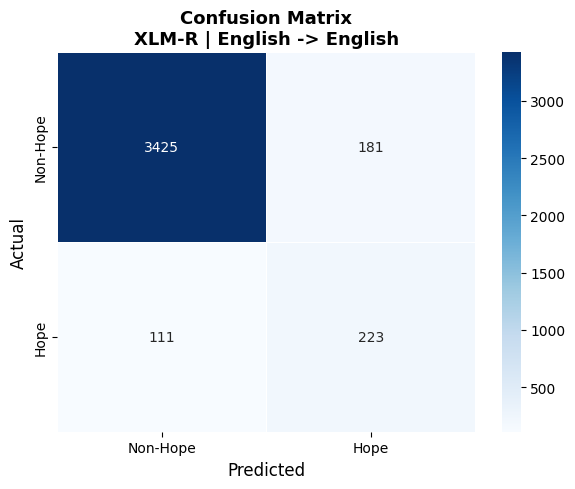

In [14]:
# ---------------------------------------------------------------------------
# Confusion matrix on the held-out test set.
# ---------------------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap=CM_CMAP,
    xticklabels=["Non-Hope", "Hope"],
    yticklabels=["Non-Hope", "Hope"],
    linewidths=0.5, ax=ax
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual",    fontsize=12)
ax.set_title(f"Confusion Matrix\n{CM_TITLE}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## 15. ROC Curve & AUC


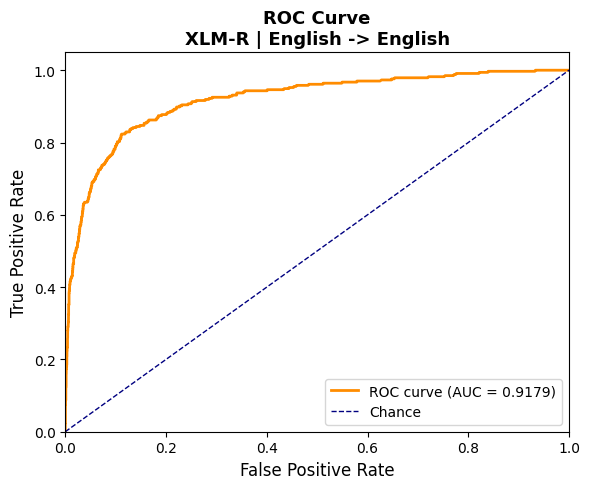

ROC AUC: 0.9179


In [15]:
# ---------------------------------------------------------------------------
# ROC curve and AUC score on the held-out test set.
# ---------------------------------------------------------------------------

fpr, tpr, _ = roc_curve(y_true, test_probs)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="darkorange", lw=2,
        label=f"ROC curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Chance")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(f"ROC Curve\n{CM_TITLE}", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")


## 16. Error Analysis
Identifies and categorises misclassified test samples.

Four lenses are applied:
1. **False Positives** — Non-Hope classified as Hope.
2. **False Negatives** — Hope classified as Non-Hope.
3. **Text-length distribution** — are errors concentrated in short or long texts?
4. **Confidence distribution** — are errors high-confidence or borderline?

These breakdowns are reported in the paper to characterise model failure modes.

Total test samples   : 3940
Correctly classified : 3648  (92.6 %)
False Positives (FP) : 181  (4.6 %)
False Negatives (FN) : 111  (2.8 %)

------------------------------------------------------------
  FALSE POSITIVES — Non-Hope predicted as Hope  (showing up to 5)
------------------------------------------------------------
  prob=0.870  | He is a fine example of a human being. We should all hope to be as honest and forward.
  prob=0.988  | I'm one of 2 girls in my Applied Engineering class in highschool. Sometimes I worry that other students or even my ...
  prob=0.754  | Islam promotes feminism like Islam promotes feminism!
  prob=0.665  | “Yep” . my god . she is demonstrating patience with these questions! This is fascinating. Her ballet teacher
  prob=0.901  | Ok.here it goes folks.OF COURSE ALL LIVES MATTER. What idiots don't get is that when people started saying Black ...

------------------------------------------------------------
  FALSE NEGATIVES — Hope predicted as Non-Hop

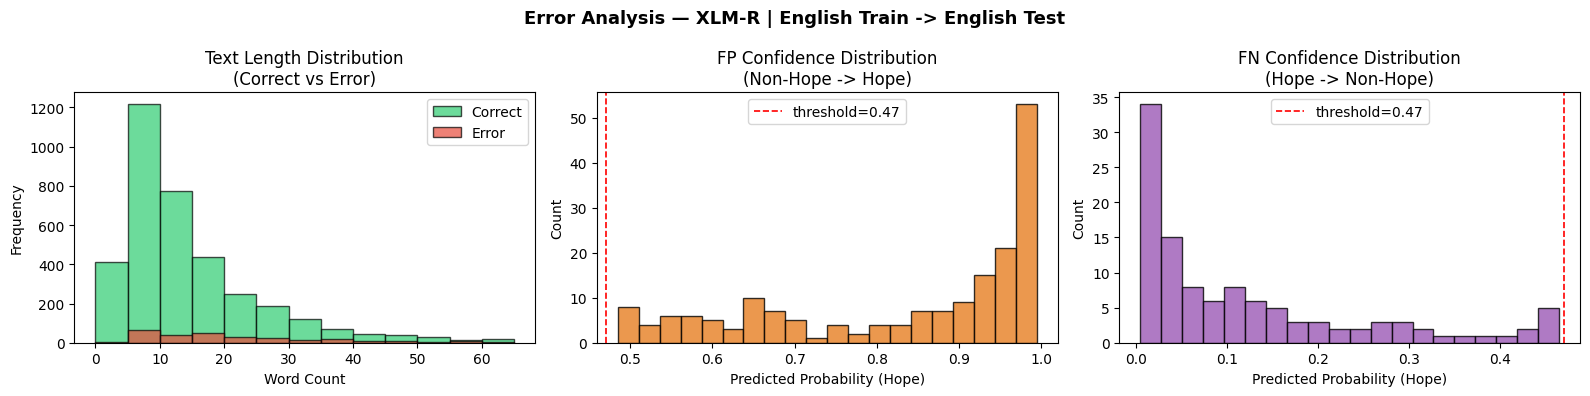


Mean predicted probability:
  FP  mean prob = 0.833  (std 0.166)
  FN  mean prob = 0.121  (std 0.131)

Errors on very short texts (<=5 words): 13  (4.5 % of all errors)


In [16]:
# ---------------------------------------------------------------------------
# Error Analysis on the held-out test set.
# ---------------------------------------------------------------------------

import textwrap

# ── Build an error dataframe ─────────────────────────────────────────────────
df_errors = df_test.copy().reset_index(drop=True).assign(
    predicted      = y_pred,
    predicted_prob = test_probs,
    correct        = (y_pred == y_true),
)

fp_df = df_errors[(df_errors["label"] == 0) & (df_errors["predicted"] == 1)]  # False Positives
fn_df = df_errors[(df_errors["label"] == 1) & (df_errors["predicted"] == 0)]  # False Negatives

print("=" * 60)
print(f"Total test samples   : {len(df_errors)}")
print(f"Correctly classified : {df_errors['correct'].sum()}  "
      f"({df_errors['correct'].mean()*100:.1f} %)")
print(f"False Positives (FP) : {len(fp_df)}  "
      f"({len(fp_df)/max(1,len(df_errors))*100:.1f} %)")
print(f"False Negatives (FN) : {len(fn_df)}  "
      f"({len(fn_df)/max(1,len(df_errors))*100:.1f} %)")
print("=" * 60)

# ── Show sample misclassified texts ──────────────────────────────────────────
def _show_samples(subset, title, n=5):
    sep = "-" * 60
    print(f"\n{sep}")
    print(f"  {title}  (showing up to {n})")
    print(sep)
    if subset.empty:
        print("  (none)")
        return
    for _, row in subset.head(n).iterrows():
        snippet = textwrap.shorten(str(row["text"]), width=120, placeholder=" ...")
        prob = row["predicted_prob"]
        print(f"  prob={prob:.3f}  | {snippet}")

_show_samples(fp_df, "FALSE POSITIVES — Non-Hope predicted as Hope")
_show_samples(fn_df, "FALSE NEGATIVES — Hope predicted as Non-Hope")

# ── Text length vs error ──────────────────────────────────────────────────────
df_errors["text_len"] = df_errors["text"].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Error Analysis — " + RESULT_TITLE, fontsize=13, fontweight="bold")

max_len_val = max(10, int(df_errors["text_len"].quantile(0.98)) + 10)
bins = list(range(0, max_len_val, 5))

axes[0].hist(df_errors[df_errors["correct"]]["text_len"],  bins=bins,
             color="#2ecc71", alpha=0.7, edgecolor="black", label="Correct")
axes[0].hist(df_errors[~df_errors["correct"]]["text_len"], bins=bins,
             color="#e74c3c", alpha=0.7, edgecolor="black", label="Error")
axes[0].set_title("Text Length Distribution\n(Correct vs Error)")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# ── Confidence distribution of FP ────────────────────────────────────────────
if fp_df.empty:
    axes[1].text(0.5, 0.5, "No False Positives", ha="center", va="center",
                 transform=axes[1].transAxes, fontsize=12, color="gray")
else:
    axes[1].hist(fp_df["predicted_prob"], bins=20, color="#e67e22",
                 alpha=0.8, edgecolor="black")
    axes[1].axvline(best_thresh, color="red", linestyle="--",
                    linewidth=1.2, label="threshold=" + str(round(best_thresh, 2)))
    axes[1].legend()
axes[1].set_title("FP Confidence Distribution\n(Non-Hope -> Hope)")
axes[1].set_xlabel("Predicted Probability (Hope)")
axes[1].set_ylabel("Count")

# ── Confidence distribution of FN ────────────────────────────────────────────
if fn_df.empty:
    axes[2].text(0.5, 0.5, "No False Negatives", ha="center", va="center",
                 transform=axes[2].transAxes, fontsize=12, color="gray")
else:
    axes[2].hist(fn_df["predicted_prob"], bins=20, color="#9b59b6",
                 alpha=0.8, edgecolor="black")
    axes[2].axvline(best_thresh, color="red", linestyle="--",
                    linewidth=1.2, label="threshold=" + str(round(best_thresh, 2)))
    axes[2].legend()
axes[2].set_title("FN Confidence Distribution\n(Hope -> Non-Hope)")
axes[2].set_xlabel("Predicted Probability (Hope)")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary statistics ────────────────────────────────────────────────────────
print("\nMean predicted probability:")
if not fp_df.empty:
    fp_mean = fp_df["predicted_prob"].mean()
    fp_std  = fp_df["predicted_prob"].std()
    print(f"  FP  mean prob = {fp_mean:.3f}  (std {fp_std:.3f})")
if not fn_df.empty:
    fn_mean = fn_df["predicted_prob"].mean()
    fn_std  = fn_df["predicted_prob"].std()
    print(f"  FN  mean prob = {fn_mean:.3f}  (std {fn_std:.3f})")

err_df    = df_errors[~df_errors["correct"]]
err_short = err_df[err_df["text_len"] <= 5]
pct       = len(err_short) / max(1, len(err_df)) * 100
print(f"\nErrors on very short texts (<=5 words): {len(err_short)}  ({pct:.1f} % of all errors)")


## 17. Save Results

In [17]:
results = {
    "experiment"      : "XLM-R | English Train -> English Test",
    "model"           : MODEL_NAME,
    "train_data"      : f"English ({len(df_train_raw)})",
    "test_data"       : f"English ({len(df_test)})",
    "threshold"       : float(best_thresh),
    "accuracy"        : round(acc,  4),
    "f1_macro"        : round(f1_m, 4),
    "f1_weighted"     : round(f1_w, 4),
    "precision_macro" : round(p,    4),
    "recall_macro"    : round(r,    4),
    "roc_auc"         : round(roc_auc, 4),
}
with open(f"{OUTPUT_DIR}/results.json", "w") as f:
    json.dump(results, f, indent=2)

df_test.copy().assign(predicted=y_pred, predicted_prob=test_probs).to_csv(
    f"{OUTPUT_DIR}/test_predictions.csv", index=False
)
trainer.save_model(f"{OUTPUT_DIR}/best_model")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/best_model")

print("All outputs saved.")
print(json.dumps(results, indent=2))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All outputs saved.
{
  "experiment": "XLM-R | English Train -> English Test",
  "model": "xlm-roberta-base",
  "train_data": "English (18386)",
  "test_data": "English (3940)",
  "threshold": 0.4700000000000002,
  "accuracy": 0.9259,
  "f1_macro": 0.7817,
  "f1_weighted": 0.929,
  "precision_macro": 0.7603,
  "recall_macro": 0.8087,
  "roc_auc": 0.9179
}


## 18. Inference on New Text

In [18]:
# ---------------------------------------------------------------------------
# Single-sample inference helper.
# Uses the same decision threshold (best_thresh) calibrated on the English
# validation set, so inference is fully consistent with reported test metrics.
# ---------------------------------------------------------------------------

def predict_hope_speech(text: str, lang_tag: str = "",
                        threshold: float = best_thresh) -> tuple:
    """
    Run inference on a single text string and display a formatted result.

    Parameters
    ----------
    text      : input string (English)
    lang_tag  : optional language identifier shown in output (e.g., "BN")
    threshold : decision threshold for Hope Speech class (default: best_thresh
                calibrated on val set -- keeps inference
                consistent with the reported test metrics)

    Returns
    -------
    tuple(label, probabilities)
      label         : "Hope Speech" or "Non-Hope Speech"
      probabilities : numpy array of shape (2,) -- [P(Non-Hope), P(Hope)]
    """
    model.eval()
    enc = tokenizer(
        text, max_length=MAX_LEN, padding="max_length",
        truncation=True, return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(**enc).logits, dim=-1).cpu().numpy()[0]

    # threshold-based decision (consistent with evaluation cell)
    pred  = 1 if probs[1] >= threshold else 0
    label = "Hope Speech" if pred == 1 else "Non-Hope Speech"

    tag = f"[{lang_tag}] " if lang_tag else ""
    print(f"{tag}Text       : {text[:80]}{'...' if len(text) > 80 else ''}")
    print(f"Prediction : {label}  (threshold={threshold:.2f}, confidence: {probs[pred]*100:.1f} %)")
    print(f"Scores     : Non-Hope={probs[0]:.4f}  |  Hope={probs[1]:.4f}\n")
    return label, probs


In [19]:
# ---------------------------------------------------------------------------
# Section 18 -- Inference on New Text.
# Threshold = best_thresh (calibrated on English val set).
# ---------------------------------------------------------------------------

# ── Hope Speech (label = 1) ─────────────────────────────────────────────────
predict_hope_speech(
    "Together we can build a brighter future for everyone.",
    lang_tag="EN"
)
predict_hope_speech(
    "There is always hope when people come together with kindness.",
    lang_tag="EN"
)
predict_hope_speech(
    "Despite the challenges, humanity has always found a way to move forward.",
    lang_tag="EN"
)

# ── Non-Hope Speech (label = 0) ─────────────────────────────────────────────
predict_hope_speech(
    "Nothing will ever get better, this world is hopeless.",
    lang_tag="EN"
)
predict_hope_speech(
    "There is no point in trying, it always ends in failure.",
    lang_tag="EN"
)
predict_hope_speech(
    "People are selfish and society will never improve.",
    lang_tag="EN"
)


[EN] Text       : Together we can build a brighter future for everyone.
Prediction : Hope Speech  (threshold=0.47, confidence: 98.3 %)
Scores     : Non-Hope=0.0173  |  Hope=0.9827

[EN] Text       : There is always hope when people come together with kindness.
Prediction : Hope Speech  (threshold=0.47, confidence: 97.7 %)
Scores     : Non-Hope=0.0227  |  Hope=0.9773

[EN] Text       : Despite the challenges, humanity has always found a way to move forward.
Prediction : Hope Speech  (threshold=0.47, confidence: 84.6 %)
Scores     : Non-Hope=0.1542  |  Hope=0.8458

[EN] Text       : Nothing will ever get better, this world is hopeless.
Prediction : Non-Hope Speech  (threshold=0.47, confidence: 94.3 %)
Scores     : Non-Hope=0.9428  |  Hope=0.0572

[EN] Text       : There is no point in trying, it always ends in failure.
Prediction : Non-Hope Speech  (threshold=0.47, confidence: 93.1 %)
Scores     : Non-Hope=0.9311  |  Hope=0.0689

[EN] Text       : People are selfish and society will neve

('Non-Hope Speech', array([0.7814974 , 0.21850257], dtype=float32))

## 19. Baseline Models: TF-IDF + Logistic Regression, TF-IDF + SVM, TF-IDF + Naive Bayes, and TF-IDF + Random Forest
Baseline classifiers trained on the **same training set** used for XLM-R (`df_train_raw`)  
and evaluated on the **same held-out test set**.  
Grid search over the validation set selects the best hyperparameters for each model.


In [20]:
# ---------------------------------------------------------------------------
# Section 18 -- Baseline Models: TF-IDF + LR, TF-IDF + SVM,
#                TF-IDF + Naive Bayes, TF-IDF + Random Forest
#
# Both baselines are trained on df_train_raw (the training set)
# and evaluated on df_test (the same held-out test set as XLM-R).
# Hyperparameters are selected by grid search evaluated on df_val.
# ---------------------------------------------------------------------------

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ParameterGrid

# ── Shared TF-IDF settings ───────────────────────────────────────────────────
TFIDF_KWARGS = dict(
    ngram_range=(1, 2),
    max_features=50_000,
    sublinear_tf=True,
    min_df=2,
)

X_train = df_train_raw["text"].tolist()
y_train = df_train_raw["label"].tolist()
X_val   = df_val["text"].tolist()
y_val   = df_val["label"].tolist()
X_test  = df_test["text"].tolist()
y_test  = df_test["label"].tolist()

# ── 1. TF-IDF + Logistic Regression ─────────────────────────────────────────
print("Grid search: TF-IDF + Logistic Regression ...")
best_lr_f1, best_lr_params, best_lr_model = 0.0, {}, None
for params in ParameterGrid({"C": [0.1, 1.0, 10.0], "max_iter": [200, 500]}):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_KWARGS)),
        ("clf",   LogisticRegression(
            C=params["C"], max_iter=params["max_iter"],
            class_weight="balanced", solver="lbfgs", random_state=SEED
        )),
    ])
    pipe.fit(X_train, y_train)
    val_f1 = f1_score(y_val, pipe.predict(X_val), average="macro")
    if val_f1 > best_lr_f1:
        best_lr_f1, best_lr_params, best_lr_model = val_f1, params, pipe

print(f"Best LR params : {best_lr_params}  (val F1-macro={best_lr_f1:.4f})")

lr_preds = best_lr_model.predict(X_test)
lr_acc   = accuracy_score(y_test, lr_preds)
lr_f1m   = f1_score(y_test, lr_preds, average="macro")
lr_f1w   = f1_score(y_test, lr_preds, average="weighted")
lr_prec  = precision_score(y_test, lr_preds, average="macro", zero_division=0)
lr_rec   = recall_score(y_test, lr_preds, average="macro", zero_division=0)
lr_probs = best_lr_model.predict_proba(X_test)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lr_auc   = auc(lr_fpr, lr_tpr)

print("\n" + "=" * 60)
print("TF-IDF + Logistic Regression -- Test Results")
print("=" * 60)
print(f"Accuracy          : {lr_acc:.4f}  ({lr_acc*100:.2f} %)")
print(f"F1 (Macro)        : {lr_f1m:.4f}")
print(f"F1 (Weighted)     : {lr_f1w:.4f}")
print(f"Precision (Macro) : {lr_prec:.4f}")
print(f"Recall (Macro)    : {lr_rec:.4f}")
print(f"ROC AUC           : {lr_auc:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, lr_preds,
      target_names=["Non-Hope Speech", "Hope Speech"], digits=4))

# ── 2. TF-IDF + LinearSVC ───────────────────────────────────────────────────
print("\nGrid search: TF-IDF + SVM (LinearSVC) ...")
best_svm_f1, best_svm_params, best_svm_model = 0.0, {}, None
for params in ParameterGrid({"C": [0.01, 0.1, 1.0, 10.0], "max_iter": [1000, 2000]}):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_KWARGS)),
        ("clf",   LinearSVC(
            C=params["C"], max_iter=params["max_iter"],
            class_weight="balanced", random_state=SEED
        )),
    ])
    pipe.fit(X_train, y_train)
    val_f1 = f1_score(y_val, pipe.predict(X_val), average="macro")
    if val_f1 > best_svm_f1:
        best_svm_f1, best_svm_params, best_svm_model = val_f1, params, pipe

print(f"Best SVM params : {best_svm_params}  (val F1-macro={best_svm_f1:.4f})")

svm_preds = best_svm_model.predict(X_test)
svm_acc   = accuracy_score(y_test, svm_preds)
svm_f1m   = f1_score(y_test, svm_preds, average="macro")
svm_f1w   = f1_score(y_test, svm_preds, average="weighted")
svm_prec  = precision_score(y_test, svm_preds, average="macro", zero_division=0)
svm_rec   = recall_score(y_test, svm_preds, average="macro", zero_division=0)
svm_scores = best_svm_model.decision_function(X_test)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_scores)
svm_auc   = auc(svm_fpr, svm_tpr)

print("\n" + "=" * 60)
print("TF-IDF + SVM (LinearSVC) -- Test Results")
print("=" * 60)
print(f"Accuracy          : {svm_acc:.4f}  ({svm_acc*100:.2f} %)")
print(f"F1 (Macro)        : {svm_f1m:.4f}")
print(f"F1 (Weighted)     : {svm_f1w:.4f}")
print(f"Precision (Macro) : {svm_prec:.4f}")
print(f"Recall (Macro)    : {svm_rec:.4f}")
print(f"ROC AUC           : {svm_auc:.4f}  (from decision_function margin, not probability)")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, svm_preds,
      target_names=["Non-Hope Speech", "Hope Speech"], digits=4))

# ── 3. TF-IDF + Naive Bayes (ComplementNB) ──────────────────────────────────
# ComplementNB is recommended for imbalanced text classification
# (Rennie et al., 2003); it corrects the standard NB weight estimate
# using complement-class statistics, which is more robust than
# MultinomialNB on skewed class distributions.
from sklearn.naive_bayes import ComplementNB
print("Grid search: TF-IDF + Naive Bayes (ComplementNB) ...")
best_nb_f1, best_nb_params, best_nb_model = 0.0, {}, None
for params in ParameterGrid({"alpha": [0.01, 0.1, 0.5, 1.0, 2.0]}):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_KWARGS)),
        ("clf",   ComplementNB(alpha=params["alpha"])),
    ])
    pipe.fit(X_train, y_train)
    val_f1 = f1_score(y_val, pipe.predict(X_val), average="macro")
    if val_f1 > best_nb_f1:
        best_nb_f1, best_nb_params, best_nb_model = val_f1, params, pipe

print(f"Best NB params : {best_nb_params}  (val F1-macro={best_nb_f1:.4f})")

nb_preds = best_nb_model.predict(X_test)
nb_acc   = accuracy_score(y_test, nb_preds)
nb_f1m   = f1_score(y_test, nb_preds, average="macro")
nb_f1w   = f1_score(y_test, nb_preds, average="weighted")
nb_prec  = precision_score(y_test, nb_preds, average="macro", zero_division=0)
nb_rec   = recall_score(y_test, nb_preds, average="macro", zero_division=0)
nb_probs = best_nb_model.predict_proba(X_test)[:, 1]
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_probs)
nb_auc   = auc(nb_fpr, nb_tpr)

print("\n" + "=" * 60)
print("TF-IDF + Naive Bayes (ComplementNB) -- Test Results")
print("=" * 60)
print(f"Accuracy          : {nb_acc:.4f}  ({nb_acc*100:.2f} %)")
print(f"F1 (Macro)        : {nb_f1m:.4f}")
print(f"F1 (Weighted)     : {nb_f1w:.4f}")
print(f"Precision (Macro) : {nb_prec:.4f}")
print(f"Recall (Macro)    : {nb_rec:.4f}")
print(f"ROC AUC           : {nb_auc:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, nb_preds,
      target_names=["Non-Hope Speech", "Hope Speech"], digits=4))

# ── 4. TF-IDF + Random Forest ────────────────────────────────────────────────
# class_weight="balanced_subsample" reweights at each bootstrap draw,
# which is more robust than a single global "balanced" weight when
# tree depth varies across estimators.
from sklearn.ensemble import RandomForestClassifier
print("\nGrid search: TF-IDF + Random Forest ...")
best_rf_f1, best_rf_params, best_rf_model = 0.0, {}, None
for params in ParameterGrid({
    "n_estimators": [100, 200],
    "max_depth":    [None, 20],
    "min_samples_leaf": [1, 3],
}):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_KWARGS)),
        ("clf",   RandomForestClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            class_weight="balanced_subsample",
            random_state=SEED,
            n_jobs=-1,
        )),
    ])
    pipe.fit(X_train, y_train)
    val_f1 = f1_score(y_val, pipe.predict(X_val), average="macro")
    if val_f1 > best_rf_f1:
        best_rf_f1, best_rf_params, best_rf_model = val_f1, params, pipe

print(f"Best RF params : {best_rf_params}  (val F1-macro={best_rf_f1:.4f})")

rf_preds = best_rf_model.predict(X_test)
rf_acc   = accuracy_score(y_test, rf_preds)
rf_f1m   = f1_score(y_test, rf_preds, average="macro")
rf_f1w   = f1_score(y_test, rf_preds, average="weighted")
rf_prec  = precision_score(y_test, rf_preds, average="macro", zero_division=0)
rf_rec   = recall_score(y_test, rf_preds, average="macro", zero_division=0)
rf_probs = best_rf_model.predict_proba(X_test)[:, 1]
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc   = auc(rf_fpr, rf_tpr)

print("\n" + "=" * 60)
print("TF-IDF + Random Forest -- Test Results")
print("=" * 60)
print(f"Accuracy          : {rf_acc:.4f}  ({rf_acc*100:.2f} %)")
print(f"F1 (Macro)        : {rf_f1m:.4f}")
print(f"F1 (Weighted)     : {rf_f1w:.4f}")
print(f"Precision (Macro) : {rf_prec:.4f}")
print(f"Recall (Macro)    : {rf_rec:.4f}")
print(f"ROC AUC           : {rf_auc:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, rf_preds,
      target_names=["Non-Hope Speech", "Hope Speech"], digits=4))

# ── 5. TF-IDF + XGBoost ──────────────────────────────────────────────────────
# XGBoost with histogram-based tree method (tree_method="hist") is fast
# on sparse TF-IDF matrices.  scale_pos_weight handles any residual class
# imbalance: set to n_negative / n_positive on the training set.
# Hyperparameters tuned by grid search on df_val (same protocol as above).
import warnings as _warnings
_warnings.filterwarnings("ignore", category=UserWarning)
_warnings.filterwarnings("ignore", category=FutureWarning)
from xgboost import XGBClassifier

_n_neg = sum(1 for y in y_train if y == 0)
_n_pos = sum(1 for y in y_train if y == 1)
_spw   = _n_neg / _n_pos if _n_pos > 0 else 1.0

print("Grid search: TF-IDF + XGBoost ...")
best_xgb_f1, best_xgb_params, best_xgb_model = 0.0, {}, None
for params in ParameterGrid({
    "n_estimators":  [100, 200],
    "max_depth":     [3, 6],
    "learning_rate": [0.05, 0.1],
}):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_KWARGS)),
        ("clf",   XGBClassifier(
            n_estimators     = params["n_estimators"],
            max_depth        = params["max_depth"],
            learning_rate    = params["learning_rate"],
            scale_pos_weight = _spw,
            tree_method      = "hist",
            eval_metric      = "logloss",
            random_state     = SEED,
            verbosity        = 0,
        )),
    ])
    pipe.fit(X_train, y_train)
    val_f1 = f1_score(y_val, pipe.predict(X_val), average="macro")
    if val_f1 > best_xgb_f1:
        best_xgb_f1, best_xgb_params, best_xgb_model = val_f1, params, pipe

print(f"Best XGB params : {best_xgb_params}  (val F1-macro={best_xgb_f1:.4f})")

xgb_preds = best_xgb_model.predict(X_test)
xgb_acc   = accuracy_score(y_test,  xgb_preds)
xgb_f1m   = f1_score(y_test,  xgb_preds, average="macro")
xgb_f1w   = f1_score(y_test,  xgb_preds, average="weighted")
xgb_prec  = precision_score(y_test, xgb_preds, average="macro", zero_division=0)
xgb_rec   = recall_score(y_test,    xgb_preds, average="macro", zero_division=0)
xgb_probs = best_xgb_model.predict_proba(X_test)[:, 1]
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
xgb_auc   = auc(xgb_fpr, xgb_tpr)

print("\n" + "=" * 60)
print("TF-IDF + XGBoost -- Test Results")
print("=" * 60)
print(f"Accuracy          : {xgb_acc:.4f}  ({xgb_acc*100:.2f} %)")
print(f"F1 (Macro)        : {xgb_f1m:.4f}")
print(f"F1 (Weighted)     : {xgb_f1w:.4f}")
print(f"Precision (Macro) : {xgb_prec:.4f}")
print(f"Recall (Macro)    : {xgb_rec:.4f}")
print(f"ROC AUC           : {xgb_auc:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds,
      target_names=["Non-Hope Speech", "Hope Speech"], digits=4))


Grid search: TF-IDF + Logistic Regression ...
Best LR params : {'C': 10.0, 'max_iter': 200}  (val F1-macro=0.7232)

TF-IDF + Logistic Regression -- Test Results
Accuracy          : 0.9071  (90.71 %)
F1 (Macro)        : 0.7390
F1 (Weighted)     : 0.9130
Precision (Macro) : 0.7137
Recall (Macro)    : 0.7754
ROC AUC           : 0.8914

Classification Report:
                 precision    recall  f1-score   support

Non-Hope Speech     0.9634    0.9340    0.9485      3606
    Hope Speech     0.4640    0.6168    0.5296       334

       accuracy                         0.9071      3940
      macro avg     0.7137    0.7754    0.7390      3940
   weighted avg     0.9210    0.9071    0.9130      3940


Grid search: TF-IDF + SVM (LinearSVC) ...
Best SVM params : {'C': 1.0, 'max_iter': 1000}  (val F1-macro=0.7134)

TF-IDF + SVM (LinearSVC) -- Test Results
Accuracy          : 0.9112  (91.12 %)
F1 (Macro)        : 0.7377
F1 (Weighted)     : 0.9148
Precision (Macro) : 0.7201
Recall (Macro)    : 0.7

## 20. Model Comparison: XLM-R vs All Baseline Models
Comparison table and grouped bar chart across all five models on the English test set.


MODEL COMPARISON -- English Test Set
Experiment: Experiment 4: English Train -> English Test
                   Model  Accuracy  F1 (Macro)  F1 (Weighted)  Precision (Macro)  Recall (Macro)  ROC AUC
             TF-IDF + LR    0.9071      0.7390         0.9130             0.7137          0.7754   0.8914
            TF-IDF + SVM    0.9112      0.7377         0.9148             0.7201          0.7599   0.8838
             TF-IDF + NB    0.9033      0.6504         0.8973             0.6727          0.6348   0.7145
             TF-IDF + RF    0.9074      0.7333         0.9122             0.7121          0.7619   0.8827
        TF-IDF + XGBoost    0.8807      0.7012         0.8935             0.6698          0.7637   0.8605
XLM-R (English->English)    0.9259      0.7817         0.9290             0.7603          0.8087   0.9179


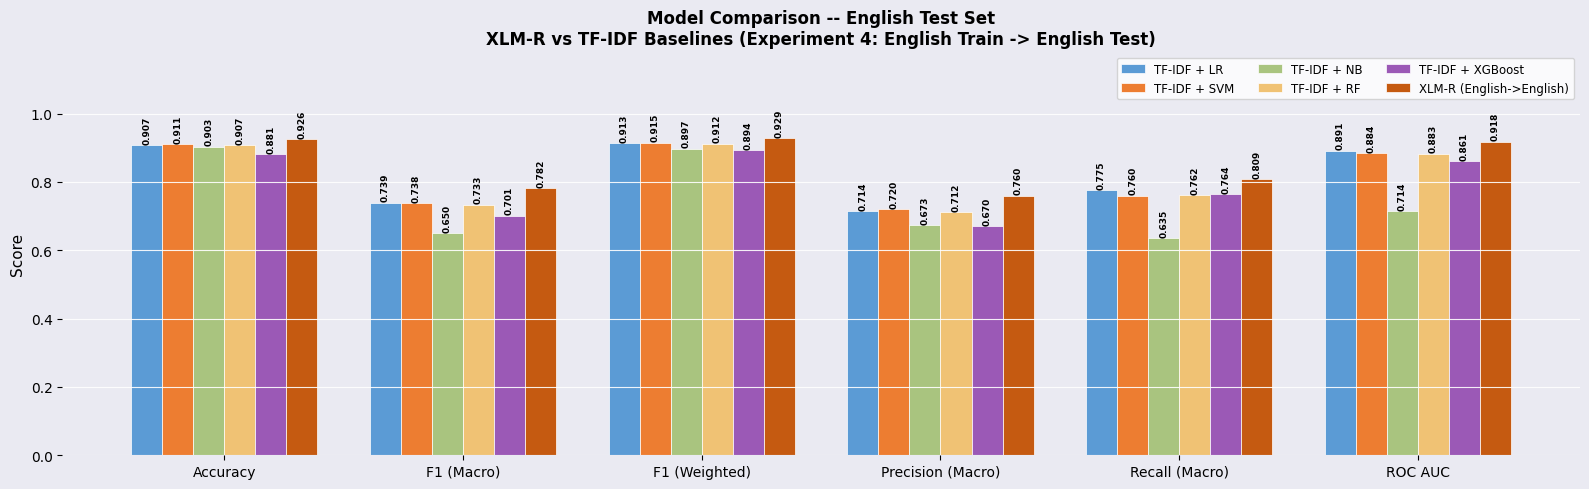

Model comparison chart saved.


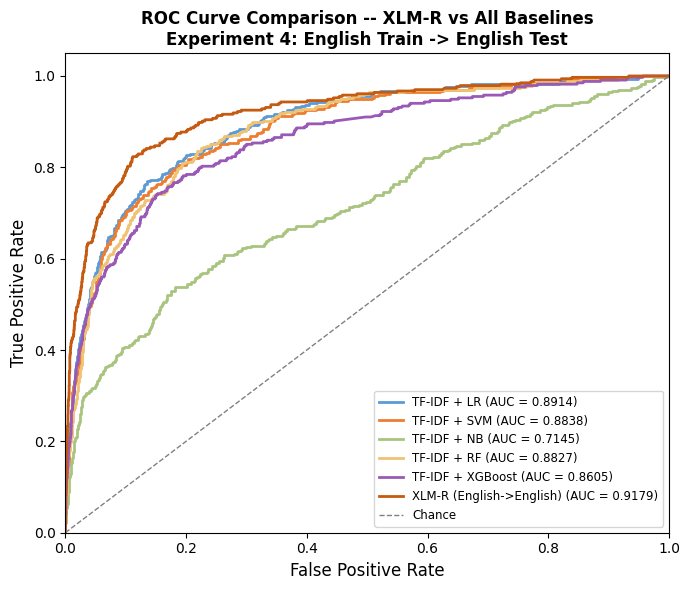

Combined ROC curve comparison saved.


In [21]:
# ---------------------------------------------------------------------------
# Section 19 -- Model Comparison: XLM-R vs All Baselines
# ---------------------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

comparison = {
    "Model": [
        "TF-IDF + LR",
        "TF-IDF + SVM",
        "TF-IDF + NB",
        "TF-IDF + RF",
        "TF-IDF + XGBoost",
        "XLM-R (English->English)",
    ],
    "Accuracy":          [lr_acc,  svm_acc,  nb_acc,  rf_acc,  xgb_acc,  acc],
    "F1 (Macro)":        [lr_f1m,  svm_f1m,  nb_f1m,  rf_f1m,  xgb_f1m,  f1_m],
    "F1 (Weighted)":     [lr_f1w,  svm_f1w,  nb_f1w,  rf_f1w,  xgb_f1w,  f1_w],
    "Precision (Macro)": [lr_prec, svm_prec, nb_prec, rf_prec, xgb_prec, p],
    "Recall (Macro)":    [lr_rec,  svm_rec,  nb_rec,  rf_rec,  xgb_rec,  r],
    "ROC AUC":           [lr_auc,  svm_auc,  nb_auc,  rf_auc,  xgb_auc,  roc_auc],
}

df_cmp = pd.DataFrame(comparison)

print("\n" + "=" * 78)
print("MODEL COMPARISON -- English Test Set")
print(f"Experiment: Experiment 4: English Train -> English Test")
print("=" * 78)
print(df_cmp.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("=" * 78)

# ── Grouped bar chart ────────────────────────────────────────────────────────
metrics   = ["Accuracy", "F1 (Macro)", "F1 (Weighted)",
             "Precision (Macro)", "Recall (Macro)", "ROC AUC"]
models    = comparison["Model"]
bar_width = 0.13
colors    = ["#5b9bd5", "#ed7d31", "#a9c47f", "#f0c274", "#9b59b6", "#c55a11"]
x         = np.arange(len(metrics))

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor("#eaeaf2")
ax.set_facecolor("#eaeaf2")
ax.grid(axis="y", color="white", linewidth=0.8, alpha=0.9)
for spine in ax.spines.values():
    spine.set_visible(False)

for i, (model, color) in enumerate(zip(models, colors)):
    vals = [comparison[m][i] for m in metrics]
    bars = ax.bar(x + i * bar_width, vals, bar_width,
                  label=model, color=color, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.004,
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=6.5, fontweight="bold", rotation=90)

ax.set_xticks(x + bar_width * 2.5)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score", fontsize=11)
ax.set_title(
    f"Model Comparison -- English Test Set\n"
    f"XLM-R vs TF-IDF Baselines (Experiment 4: English Train -> English Test)",
    fontsize=12, fontweight="bold"
)
ax.legend(loc="upper right", fontsize=8.5, ncol=3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Model comparison chart saved.")

# ── Combined ROC Curve Comparison ───────────────────────────────────────────
roc_data = {
    "TF-IDF + LR":      (lr_fpr,  lr_tpr,  lr_auc),
    "TF-IDF + SVM":     (svm_fpr, svm_tpr, svm_auc),
    "TF-IDF + NB":      (nb_fpr,  nb_tpr,  nb_auc),
    "TF-IDF + RF":      (rf_fpr,  rf_tpr,  rf_auc),
    "TF-IDF + XGBoost": (xgb_fpr, xgb_tpr, xgb_auc),
    "XLM-R (English->English)": (fpr, tpr, roc_auc),
}

fig, ax = plt.subplots(figsize=(7, 6))
for (model_label, (m_fpr, m_tpr, m_auc)), color in zip(roc_data.items(), colors):
    ax.plot(m_fpr, m_tpr, color=color, lw=2,
            label=f"{model_label} (AUC = {m_auc:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Chance")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(
    f"ROC Curve Comparison -- XLM-R vs All Baselines\nExperiment 4: English Train -> English Test",
    fontsize=12, fontweight="bold"
)
ax.legend(loc="lower right", fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curve_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Combined ROC curve comparison saved.")
